# _An Operational Objective Analysis System_

## Cressman, 1959

Este notebook apresenta dois exemplos da aplicação das ideias de Cressman (1959) para a determinação de uma análise utilizando um background, observações e pesos (determinados em função da distância entre observações e background), utilizando para isto raios de influência determinados de forma empírica onde observações são consideradas na assimilação de forma iterativa. Este método ficou conhecido como "Método de Correções Sucessivas".

A análise de Cressman (1959) funciona da seguinte forma:

1. Inicia-se com um campo de background;
2. Utiliza-se as observações distribuídas de forma irregular no espaço;
3. Ajusta-se iterativamente o background em direções às observações:
   * Inicia-se com um raio de influência grande;
   * Reduz-se o raio de influência até que o campo de background convirja para as observações.

Formulação do método de correções sucessivas (seguindo Kalnay, 2003):

$$
f^{n+1}_{i} = f^{n}_{i} + \Bigg[ \frac{\sum^{K^{n}_{i}}_{k=1}w^{n}_{ik}(f^{O}_{k}-f^{n}_{k})}{\sum^{K^{n}_{i}}_{k=1}w^{n}_{ik}+\varepsilon^{2}} \Bigg]\quad \text{ou} \quad f^{n+1}_{i} = f^{n}_{i} + W(f^{O}_{k}-f^{n}_{k})\quad \text{,} \quad W = \frac{\sum^{K^{n}_{i}}_{k=1}w^{n}_{ik}}{\sum^{K^{n}_{i}}_{k=1}w^{n}_{ik}+\varepsilon^{2}}
$$

* Onde,
  * $f^{n+1}_{i}$ é a enésima estimativa no ponto de grade $i$
  * $f^{O}_{k}$ é a k-ésima observação ao redor do ponto de grade $i$
  * $f^{n}_{k}$ é o valor do enésimo campo de background no ponto de observação $k$
  * $K^{n}_{i}$ é o número de observações dentro da distância $R^{n}$ do ponto de grade $i$
  * $\varepsilon^{2}$ é a estimativa da razão entre a variância do erro da observação e o da variância do erro do background


![Raio de Influência](./figs/raio.png)

No Método de Correções Sucessivas de Cressman, os pesos $w^{n}_{ik}$ são definidos como:
  
$$
\begin{cases}
w^{n}_{ik} = \dfrac{R^{2}_{n} - r_{ik}^{2}}{R^{2}_{n} + r_{ik}^{2}}, & r_{ik}^{2} \leq R^{2}_{n} \\
w^{n}_{ik} = 0, & r_{ik}^{2} \gt R^{2}_{n}
\end{cases}
$$

* Onde,
  * $r_{ik}^{2}$ é o quadrado da distância entre um ponto de observação $r_{k}$ e um ponto de grade $r_{i}$
  * $R^{2}_{n}$ é o quadrado do enésimo raio de influência
  
**Nota:** Observações mais próximas têm maior peso.

## Exemplo 1D

### Definição do modelo

Considere um modelo matemático simples, a função seno com a adição de um ruído normalmente distribuído:

$$
f(x) = \sin(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad -\pi \le x \le \pi
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.arange(-np.pi, np.pi, 0.01)
xb_seno = np.sin(x)

sigma = 0.5  # desvio-padrão do ruído
#ruido = np.random.randn(len(x)) * sigma
ruido = np.random.randn(*x.shape) * sigma 

xb = xb_seno + ruido

### Determinação das observações

In [3]:
# Posições
obs_pos = np.array([-2.2, -2.1, -2.0, -1.8, 0.9, 1, 2, 3])

# Valores medidos
obs_vals = np.array([-2.2, -1.8, 0.9, 0, 1, 2, 3, 4]) 

### Determinação dos pesos

In [4]:
# Função peso Cressman 
def weight(r, R):
    w = (R**2 - r**2) / (R**2 + r**2 + 1e-12)
    w[r >= R] = 0.0
    return w

### Definição dos raios de influência

In [5]:
# Raios das passagens sucessivas (do maior para o menor)
radii = [3.0, 2.0, 1.0, 0.5, 0.25, 0.175]

In [6]:
xa = xb.copy()

for R in radii:
    increments = np.zeros_like(xa)
    denom = np.zeros_like(xa)
    for xo, yo in zip(obs_pos, obs_vals):
        r = np.abs(x - xo)
        w = weight(r, R)
        increments += w * (yo - xa)
        denom += w
    # evitar divisão por zero
    mask = denom > 0
    xa[mask] += increments[mask] / denom[mask]

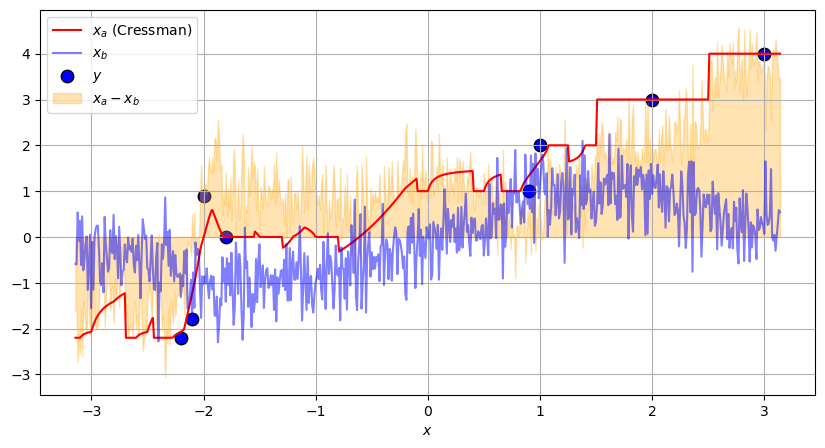

In [7]:
plt.figure(figsize=(10,5))
plt.plot(x, xa, 'r-', label='$x_a$ (Cressman)')
plt.plot(x, xb, 'b-', label='$x_b$', alpha=0.5)
plt.scatter(obs_pos, obs_vals, c='blue', s=80, edgecolor='k', label='$y$')
plt.fill_between(x, xa-xb, 0, color="orange", alpha=0.3, label="$x_{a}-x_{b}$")

# Adiciona a linha tracejada com o raio utilizado na última passagem
#ax = plt.gca()
#for x0, y0 in zip(obs_pos, obs_vals):
#    ax.hlines(y0, x0-R, x0+R, colors="green", linestyles="--", linewidth=2)
#    ax.plot([x0-R, x0+R], [y0, y0], "go")

plt.xlabel('$x$')
plt.legend()
plt.grid(True)
plt.show()

## Exemplo 2D

### Definição do modelo

In [8]:
lon = np.linspace(-np.pi, np.pi, 10)
lat = np.linspace(-np.pi, np.pi, 10)

LON, LAT = np.meshgrid(lon, lat)

In [9]:
xb_seno = np.sin(LON)

sigma = 0.5  # desvio-padrão do ruído
#ruido = np.random.randn(len(LON)) * sigma 
ruido = np.random.randn(*LON.shape) * sigma

xb = xb_seno + ruido

### Determinação das observações

In [10]:
## observações (lon, lat) e valores
#obs_locs = np.array([[-6, -4],
#                     [-2,  3],
#                     [ 3, -1],
#                     [ 6,  6]])
#obs_vals = np.array([12.0, 17.5, 20.0, 25.0])

In [11]:
# Conjunto de observações 3
#
# Posições
#
#obs_locs = np.array([[-2, -2],
#                    [0, 0],
#                    [2, 2]]) 
#
# Valores medidos
#
#obs_vals = np.array([-1.5, -1.0, 0.5]) 

In [12]:
# Conjunto de observações 2
#
# Posições
#
#obs_locs = np.array([[-2, -2],
#                    [-1, -1],
#                    [0, 0],
#                    [1, 1],
#                    [2, 2]])      
# Valores medidos
#
#obs_vals = np.array([-1.0, -1.5, -1.0, 0, -0.5])  

In [13]:
# Conjunto de observações 1
#
# Posições
#
#obs_locs = np.array([[-2.2, -1],
#                    [-2.1, 0.5],
#                    [-2.0, -0.5],
#                    [-1.8, 2],
#                    [0.9, -2.8],
#                    [1, 1],
#                    [2, 0],
#                    [3, 0.5]])      
#
# Valores medidos
#
#obs_vals = np.array([-1.0, -1.5, -2.0, -1, 1, 0, 0.5, 0]) 

In [14]:
# --- Conjunto de observações
#obs_locs = np.array([[-2.2, -1],
#                     [-2.1,  0.5],
#                     [-2.0, -0.5],
#                     [-1.8,  2],
#                     [ 0.9, -2.8],
#                     [ 1.0,  1.0],
#                     [ 2.0,  0.0],
#                     [ 3.0,  0.5]])      
#
#obs_vals = np.array([-1.0, -1.5, -2.0, -1.0, 1.0, 0.0, 0.5, 0.0]) 

In [15]:
# --- Conjunto de observações
obs_locs = np.array([[-2.2, -1],
                     [-2.1,  0.5],
                     [-2.0, -0.5],
                     [-1.8,  2],
                     [ 0.9, -2.8],
                     [ 1.0,  1.0],
                     [ 2.0,  0.0],
                     [ 3.0,  0.5]])      

obs_vals = np.array([-1.0, -1.5, -2.0, -1.0, 1.0, 0.0, 0.5, 0.0]) 

### Determinação dos pesos

In [16]:
def weight2d(dx, dy, R):
    r2 = dx**2 + dy**2
    R2 = R**2
    w = (R2 - r2) / (R2 + r2 + 1e-12)
    w[r2 >= R2] = 0.0
    return w

### Definição dos raios de influência

In [17]:
# Raios das passagens sucessivas (do maior para o menor)
radii = [3.0, 2.5, 2.0, 1.5, 1.0, 0.5]

In [18]:
xa = xb.copy()

for R in radii:
    inc = np.zeros_like(xa)
    denom = np.zeros_like(xa)
    for (xo, yo), obs in zip(obs_locs, obs_vals):
        dx = LON - xo
        dy = LAT - yo
        w = weight2d(dx, dy, R)
        inc += w * (obs - xa)
        denom += w
    mask = denom > 0
    xa[mask] += inc[mask] / denom[mask]

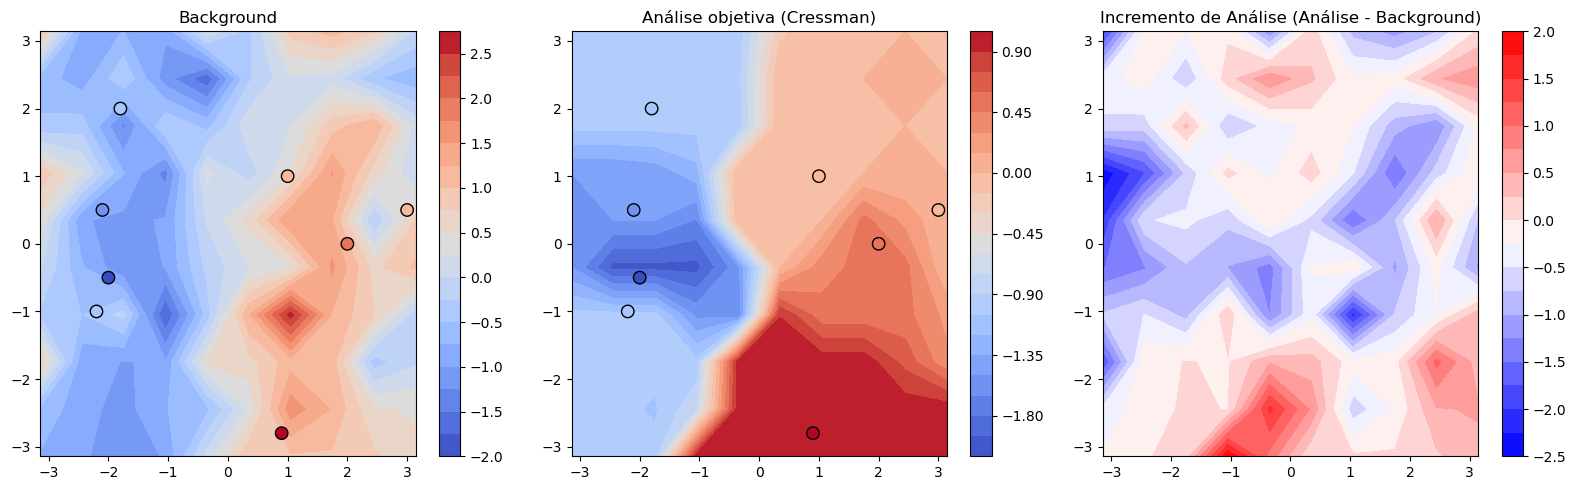

In [19]:
# Plots: fundo, análise, inovação
fig, axs = plt.subplots(1, 3, figsize=(16,5))
cf0 = axs[0].contourf(LON, LAT, xb, 20, cmap="coolwarm")
axs[0].scatter(obs_locs[:,0], obs_locs[:,1], c=obs_vals, edgecolor='k', cmap="coolwarm", s=80)
axs[0].set_title('Background')

cf1 = axs[1].contourf(LON, LAT, xa, 20, cmap="coolwarm")
axs[1].scatter(obs_locs[:,0], obs_locs[:,1], c=obs_vals, edgecolor='k', cmap="coolwarm", s=80)
axs[1].set_title('Análise objetiva (Cressman)')
cf2 = axs[2].contourf(LON, LAT, xa - xb, 20, cmap="bwr")
axs[2].set_title('Incremento de Análise (Análise - Background)')

for c in (cf0, cf1, cf2):
    plt.colorbar(c, ax=axs.tolist()[ [cf0,cf1,cf2].index(c) ])

plt.tight_layout()
plt.show()

## Perguntas

Para ambos os casos (1D e 2D):

1. O que acontece com a análise de Cressman quando apenas 1 correção é feita? Utilize os valores 3.0, 2.0, 1.0, 0.5, 0.25, 0.175, compare as análises produzidas e discuta.
2. O que acontece com a análise de Cressman quando (compare as análises produzidas e discuta):
    a. 2 correções são feitas? Utilize os valores 3.0 e 2.0.
    b. 3 correções são feitas? Utilize os valores 3.0, 2.0 e 1.0.
    c. 4 correções são feitas? Utilize os valores 3.0, 2.0, 1.0 e 0.5.
    d. 5 correções são feitas? Utilize os valores 3.0, 2.0, 1.0, 0.5 e 0.25.
    e. 6 correções são feitas? Utilize os valores 3.0, 2.0, 1.0, 0.5, 0.25 e 0.175.
3. O que acontece com a análise de Cressman quando o termo $1e-12$ é omitido? Que termo é este e qual é a sua função?
4. Quais são as diferenças entre o método de correções sucessivas e os demais métodos de análise empírica que já foram estudados?